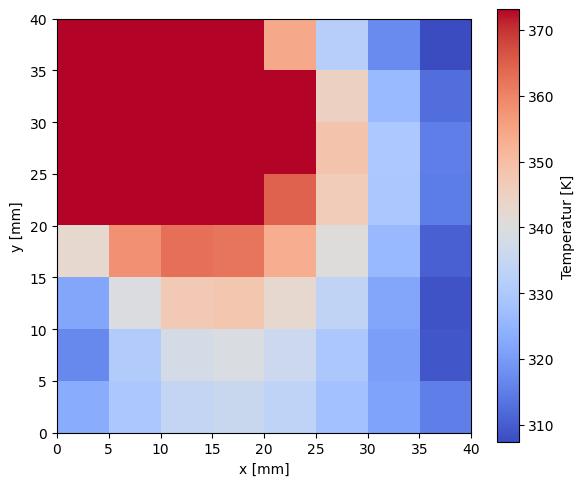

In [30]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time



def solve_temperature(n, L=40e-3, T_source=373.15):
    dx = L / n
    dy = dx
    N = n * n
    L_mm = L * 1e3

    #  Materiale und parameter 
    k_holz   = 0.10       #   Holz
    k_gips   = 0.20       #  Gips
    k_silber = 430.0      #  Silber
    h_holz   = 23.0       # W/m^2k  Wärmeübergangskoeffizient
    T_inf    = 294.15     # 21°C Raumtemperatur

    idx = lambda i, j: i * n + j
    def harmonic(k1, k2):
        s = k1 + k2
        return 0.0 if s == 0 else 2.0 * k1 * k2 / s

    # Geometrie
    k = np.full((n, n), k_holz, dtype=float)   # Standard = Holz
    i_D, j_D = n//2 , n//2
    k[:i_D, :j_D] = k_silber                 # links oben = Silber
    k[:i_D, j_D:] = k_gips                   # rechts oben = Gips

    # Dirichlet-Wärmequellen oben in der Mitte
    hot_pts_1based = [(n//4, n//2), (n//4, n//2+1), (n//4+1, n//2+1), (n//4+1, n//2+1)]
    hot_pts = [(r-1, c-1) for (r, c) in hot_pts_1based]

    dirichlet_mask = np.zeros_like(k, dtype=bool)
    for (ii, jj) in hot_pts:
        if 0 <= ii < n and 0 <= jj < n:
            dirichlet_mask[ii, jj] = True
        else:
            raise ValueError(f"Wärmequelle außerhalb des Bereichs: {(ii, jj)} für n={n}")

    # Sparse-Matrix Aufbau 
    rows, cols, data = [], [], []
    S = sp.lil_matrix((N, 1))

    for i in range(n):
        for j in range(n):
            p = idx(i, j)

            # Dirichlet-Bedingung: Wärmequelle
            if dirichlet_mask[i, j]:
                rows.append(p); cols.append(p); data.append(1.0)
                S[p, 0] = T_source
                continue

            # Leitwerte zu Nachbarn 
            kE = harmonic(k[i, j], k[i, j + 1]) if j < n - 1 else 0.0
            kW = harmonic(k[i, j], k[i, j - 1]) if j > 0     else 0.0
            kN = harmonic(k[i - 1, j], k[i, j]) if i > 0     else 0.0
            kS = harmonic(k[i, j], k[i + 1, j]) if i < n - 1 else 0.0

            aE, aW, aN, aS = kE, kW, kN, kS
            aP = aE + aW + aN + aS

            if j < n - 1:
                rows.append(p); cols.append(idx(i, j + 1)); data.append(-aE)
            if j > 0:
                rows.append(p); cols.append(idx(i, j - 1)); data.append(-aW)
            if i > 0:
                rows.append(p); cols.append(idx(i - 1, j)); data.append(-aN)
            if i < n - 1:
                rows.append(p); cols.append(idx(i + 1, j)); data.append(-aS)

            # Cauchy-Randbedingung
            
                if i == 0:       # Nordrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
                if i == n - 1:   # Südrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
                if j == 0:       # Westrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
                if j == n - 1:   # Ostrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf

            # Diagonale
            rows.append(p); cols.append(p); data.append(aP)

    #Solve
    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    T_vec = spla.spsolve(A, S.tocsr())
    T_field = T_vec.reshape((n, n))
    return T_field

# Plot
if __name__ == "__main__":
    n = 8                 
    L = 40e-3               
    T = solve_temperature(n, L=L, T_source=373.15)

    L_mm = L * 1e3
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(T, origin="upper", extent=[0, L_mm, 0, L_mm],
                   interpolation="nearest", cmap="coolwarm")
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("Temperatur [K]")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
    ax.set_aspect("equal")
    plt.tight_layout(); plt.show()



s values: [3, 4, 5, 6, 7, 8]
Absolute errors: [np.float64(35.66813725701977), np.float64(0.3101280279543289), np.float64(0.20762241839498757), np.float64(0.12814194361180853), np.float64(0.061069878276202874), np.float64(0.0)]
Relative errors: [np.float64(0.09570887141569628), np.float64(0.0008321728794379141), np.float64(0.0005571175831562669), np.float64(0.0003438460082457177), np.float64(0.000163870119733715), np.float64(0.0)]
Compute times [s]: [0.0009999275207519531, 0.003999948501586914, 0.01100015640258789, 0.04399991035461426, 0.17799997329711914, 1.000999927520752]


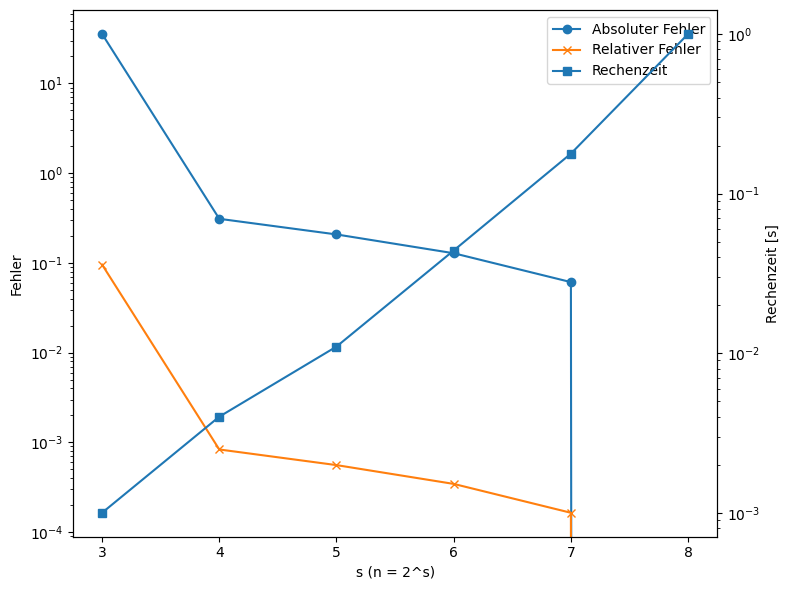

In [45]:
import numpy as np
import time
import matplotlib.pyplot as plt

def grid_analysis(L=40e-3, ref_points=None):
    if ref_points is None:
        n = 8
        ref_points = [
            (1, 1),                
            (1, n-2),
            (n-2, 1),
            (n-2, n-3),
            (n//2, 3*n//4)         
        ]
    
    # Gittergrößen: n = 2^s
    s_list = list(range(3, 9))          # s = 3...8
    n_list = [2**s for s in s_list]     # n = 8,16,32,64,128,256
    
    # Referenzlösung 
    n_ref = n_list[-1]
    T_ref = solve_temperature(n_ref, L)

    absolute_errors = []
    relative_errors = []
    compute_times = []

    for n in n_list:
        start_time = time.time()
        T = solve_temperature(n, L)
        end_time = time.time()
        compute_time = end_time - start_time
        
        abs_error = []
        rel_error = []

        for (i, j) in ref_points:
            T_ref_point = T_ref[i, j]
            T_point = T[i, j]
            abs_error.append(abs(T_point - T_ref_point))
            rel_error.append(abs(T_point - T_ref_point) /T_ref_point )

        absolute_errors.append(np.mean(abs_error))
        relative_errors.append(np.mean(rel_error))
        compute_times.append(compute_time)

    return s_list, absolute_errors, relative_errors, compute_times


# Plot 
s_list, abs_errors, rel_errors, compute_times = grid_analysis()
print("s values:", s_list)
print("Absolute errors:", abs_errors)
print("Relative errors:", rel_errors)
print("Compute times [s]:", compute_times)

fig, ax1 = plt.subplots(figsize=(8, 6))

# y-Achse links
ax1.set_xlabel("s (n = 2^s)")
ax1.set_ylabel("Fehler")
l1, = ax1.semilogy(s_list, abs_errors, label="Absoluter Fehler", marker='o')
l2, = ax1.semilogy(s_list, rel_errors, label="Relativer Fehler", marker='x')

# y-Achse rechts
ax2 = ax1.twinx()
ax2.set_ylabel("Rechenzeit [s]")
l3, = ax2.semilogy(s_list, compute_times, label="Rechenzeit", marker='s')


lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="upper right")


plt.tight_layout()
plt.show()

